### Import Modules


In [1]:
# Standard Library
import random, traceback
from collections.abc import Callable, Generator
from contextlib import contextmanager
from datetime import datetime, timezone
from IPython.display import display
from pathlib import Path
from typing import Any

# Packages
import mlflow, numpy, optuna, pandas, torch
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from matplotlib import pyplot, ticker
from matplotlib.figure import Figure
from mlflow import ActiveRun, MlflowClient
from mlflow.models import infer_signature, ModelSignature
from mlflow.models.model import ModelInfo
from mlflow.pyfunc import PythonModel, PythonModelContext
from numpy import ndarray
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler
from torch import multiprocessing, nn, optim, Tensor
from torch.nn import functional
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from xgboost import XGBClassifier

C:\Projects\Personal\Practice\fraud-detection-platform\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants & Config


In [2]:
# Paths
ROOT_DIR = Path("../").resolve()

# Data
TEST_SIZE = 0.2
START_DATE = datetime(2013, 9, 1, tzinfo=timezone.utc)
SEED_PATH = (
    ROOT_DIR
    / "database"
    / "seed"
    / "transaction_inferences"
    / "creditcard_transactions.csv.gz"
)

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
numpy.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Cross Validation
CV_VAL_SIZE = TEST_SIZE / (1 - TEST_SIZE)
CV = StratifiedKFold(
    n_splits=int(1 / CV_VAL_SIZE), shuffle=True, random_state=RANDOM_STATE
)

# Hyperparameter Optimization
BAYES_STEPS = 30
TRAINING_TIMEOUT_SECONDS = 3_600
ACTIVATION_MAP = {"relu": nn.ReLU, "gelu": nn.GELU, "silu": nn.SiLU}

# Torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE.type}")
multiprocessing.set_start_method("spawn", force=True)

# optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

# MLflow
MLFLOW_DIR = Path("./mlflow").resolve()
MLFLOW_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{(MLFLOW_DIR / "mlflow.db").as_posix()}")
EXPERIMENT_NAME = "fraud-detection"
if not mlflow.get_experiment_by_name(EXPERIMENT_NAME):
    mlflow.create_experiment(
        name=EXPERIMENT_NAME,
        artifact_location=(MLFLOW_DIR / "artifacts").as_uri(),
    )
mlflow.set_experiment(EXPERIMENT_NAME)

Device: cpu


<Experiment: artifact_location='file:///C:/Projects/Personal/Practice/fraud-detection-platform/notebooks/mlflow/artifacts', creation_time=1790937425064, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790937425064, lifecycle_stage='active', name='fraud-detection', tags={}, trace_location=None, workspace='default'>

### Helpers: Evaluation


In [3]:
def get_predictions_pyfunc(
    model: PythonModel,
    x: ndarray,
    threshold: float = 0.5,
) -> dict[str, ndarray]:
    return {
        "y_pred": model.predict(None, x, params={"threshold": threshold}),
        "y_prob": model.predict(None, x, params={"probabilities": True})[:, 1],
    }

def get_predictions_pipeline(
    model: Pipeline,
    x: ndarray,
    threshold: float = 0.5,
) -> dict[str, ndarray]:
    y_prob = model.predict_proba(x)[:, 1]
    return {
        "y_pred": (y_prob >= threshold).astype(int),
        "y_prob": y_prob
    }

In [4]:
def evaluate_model_predictions(
    y_pred: ndarray,
    y_prob: ndarray,
    y_true: ndarray,
) -> dict[str, float]:
    return {
        "F1 score": f1_score(y_true, y_pred),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Accuracy": accuracy_score(y_true, y_pred),
    }

def visualize_model_predictions(
    title: str,
    y_pred: ndarray,
    y_prob: ndarray,
    y_true: ndarray,
    threshold: float = 0.5,
) -> dict[str, Figure]:
    confusion_matrix_figure, confusion_matrix_ax = pyplot.subplots()
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["Legitimate", "Fraud"],
        normalize="true",
        cmap="Blues",
        values_format=".1%",
        ax=confusion_matrix_ax,
    )
    confusion_matrix_ax.set_title(title)

    probability_scatter_figure, probability_scatter_ax = pyplot.subplots()
    probability_scatter_ax.scatter(
        y_prob,
        range(len(y_true)),
        c=numpy.where(y_true == 1, "red", "blue"),
        edgecolors="k",
    )
    probability_scatter_ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    probability_scatter_ax.axvline(
        x=threshold, alpha=0.3, color="white", linestyle="--"
    )
    probability_scatter_ax.axvspan(threshold, 1.0, alpha=0.05, color="red")
    probability_scatter_ax.axvspan(0.0, threshold, alpha=0.05, color="blue")
    probability_scatter_ax.set_yticks([])
    probability_scatter_ax.set_ylabel("Transactions")
    probability_scatter_ax.set_xlabel("Fraud Probability Score")
    probability_scatter_ax.set_title(title)

    return {
        f"probability_scatter_{title.lower()}": probability_scatter_figure,
        f"confusion_matrix_{title.lower()}": confusion_matrix_figure,
    }

def evaluate_model(
    *,
    model: Pipeline | PythonModel,
    model_input: ndarray,
    y_true: ndarray,
    title: str,
) -> tuple[dict[str, ndarray], dict[str, float], dict[str, Figure]]:
    predictions = (
        get_predictions_pyfunc(model, model_input)
        if isinstance(model, PythonModel)
        else get_predictions_pipeline(model, model_input)
    )
    metrics = evaluate_model_predictions(**predictions, y_true=y_true)
    figures = visualize_model_predictions(**predictions, y_true=y_true, title=title)
    return predictions, metrics, figures

### Helpers: Tuning


In [5]:
def optimize_hyperparameters(
    objective: Callable[[optuna.Trial], float],
    multivariate: bool,
) -> optuna.Study:
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(
            seed=RANDOM_STATE,
            multivariate=multivariate,
        ),
    )
    study.optimize(
        objective,
        n_trials=BAYES_STEPS,
        n_jobs=1,
        show_progress_bar=True,
        gc_after_trial=True,
        timeout=TRAINING_TIMEOUT_SECONDS,
    )
    return study

### Helpers: MLflow


In [6]:
@contextmanager
def transactional_mlflow_run(run_name: str) -> Generator[ActiveRun, Any, None]:
    with mlflow.start_run(run_name=run_name) as run:
        try:
            yield run
        except Exception:
            run_id_str = str(run.info.run_id)
            client = MlflowClient()
            mlflow.delete_run(run_id_str)
            try:
                versions = client.search_model_versions(f"run_id='{run_id_str}'")
                for version in versions:
                    client.delete_model_version(
                        name=version.name,
                        version=version.version,
                    )
            except Exception:
                pass
            traceback.print_exc()

def log_model_run(
    *,
    model: Pipeline | PythonModel,
    registered_model_name: str,
    signature: ModelSignature,
    input_example: ndarray,
    pip_requirements: list[str],
    params: dict[str, object],
    metrics: dict[str, float],
    figures: dict[str, Figure],
    skops_trusted_types: list[str] | None = None,
) -> ModelInfo:
    if isinstance(model, Pipeline):
        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            registered_model_name=registered_model_name,
            signature=signature,
            input_example=input_example,
            pip_requirements=pip_requirements,
            name="model",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_SKOPS,
            skops_trusted_types=skops_trusted_types,
            pyfunc_predict_fn=model.predict_proba.__name__
        )
    else:
        model_info = mlflow.pyfunc.log_model(
            python_model=model,
            registered_model_name=registered_model_name,
            signature=signature,
            input_example=input_example,
            pip_requirements=pip_requirements,
            name="model",
        )

    mlflow.log_params(params=params, run_id=model_info.run_id)
    mlflow.log_metrics(
        metrics=metrics,
        run_id=model_info.run_id,
        model_id=model_info.model_id,
    )
    for figure_name, figure in figures.items():
        pyplot.show()
        mlflow.log_figure(figure, f"{figure_name}.png")
        pyplot.close(figure)
    return model_info

### Load Data


In [7]:
seed_df = pandas.read_csv(
    SEED_PATH,
    compression="gzip",
    dtype={
        "Time": "float64",
        **{f"V{i}": "float64" for i in range(1, 29)},
        "Amount": "float64",
        "Class": "int8",
    },
)

df = pandas.DataFrame({
    "is_fraud": seed_df["Class"].astype("int64"),
    "transaction_timestamp": (
        START_DATE.timestamp() + seed_df["Time"]
    ).astype("int64"),
    "amount": seed_df["Amount"],
    **{f"v{i}": seed_df[f"V{i}"] for i in range(1, 29)},
})

x = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

train_x, test_x, train_y, test_y = train_test_split(
    x, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_x_np = train_x.to_numpy(dtype=numpy.float64)
train_y_np = train_y.to_numpy(dtype=numpy.int64)
test_x_np = test_x.to_numpy(dtype=numpy.float64)
test_y_np = test_y.to_numpy(dtype=numpy.int64)

train_x_np_dimensions_size = train_x_np.shape[1]

print(f"Data shape: {df.shape}")
print(f"Train: {train_x.shape}, Test: {test_x.shape}")

Data shape: (284807, 31)
Train: (227845, 30), Test: (56962, 30)


### KNN


C:\Users\MSI Laptop\AppData\Local\Temp\ipykernel_18164\3265611493.py:7: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=TPESampler(
[I 2026-10-02 20:30:32,329] A new study created in memory with name: no-name-054a1956-b04f-440e-80e6-ca2bea082336
  0%|          | 0/30 [01:08<?, ?it/s]

[I 2026-10-02 20:31:41,243] Trial 0 finished with value: 0.5561327236287912 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'p': 2, 'leaf_size': 69}. Best is trial 0 with value: 0.5561327236287912.


Best trial: 0. Best value: 0.556133:   7%|▋         | 2/30 [02:23<33:32, 71.87s/it, 143.11/3600 seconds]

[I 2026-10-02 20:32:55,267] Trial 1 finished with value: 0.5402513333619152 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'p': 2, 'leaf_size': 103}. Best is trial 0 with value: 0.5561327236287912.


Best trial: 0. Best value: 0.556133:   7%|▋         | 2/30 [07:46<33:32, 71.87s/it, 143.11/3600 seconds]

...

[I 2026-10-02 21:32:56,375] Trial 17 finished with value: 0.6253341903532799 and parameters: {'n_neighbors': 29, 'weights': 'uniform', 'p': 1, 'leaf_size': 88}. Best is trial 13 with value: 0.6325308179622856.


Best trial: 13. Best value: 0.632531:  60%|██████    | 18/30 [1:02:24<41:36, 208.01s/it, 3744.23/3600 seconds]


KNN
  Best Hyperparameters: {'n_neighbors': 30, 'weights': 'distance', 'p': 1, 'leaf_size': 95}


,Metric,Score
0,F1 score,0.255977
1,PR-AUC,0.646526
2,Recall,0.928571
3,Precision,0.148450
4,ROC-AUC,0.963075
5,Accuracy,0.990713


2026/10/02 21:36:05 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Projects\Personal\Practice\fraud-detection-platform\notebooks
2026/10/02 21:36:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'KNN' already exists. Creating a new version of this model...
Created version '2' of model 'KNN'.


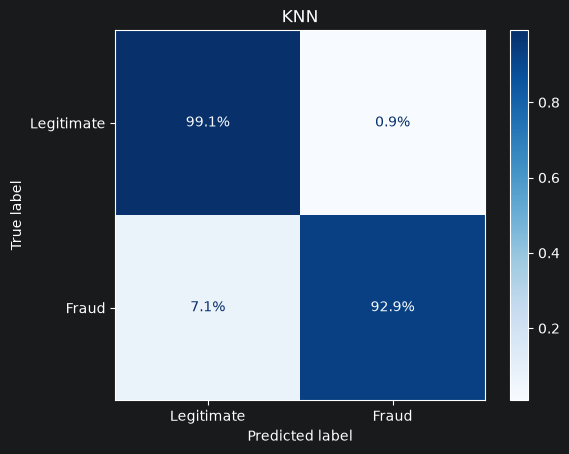

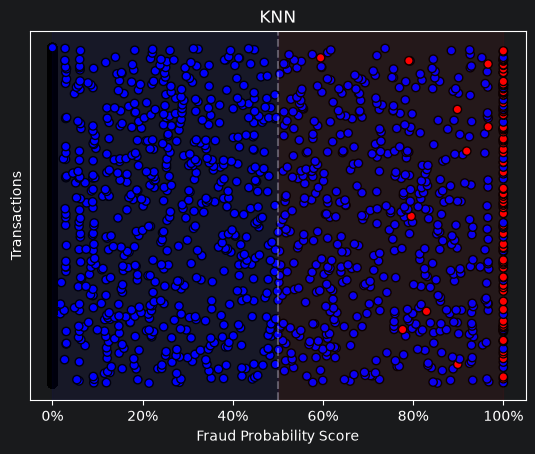

In [8]:
with transactional_mlflow_run(run_name="KNN") as run:
    model_name = "knn"
    run_name_str = str(run.info.run_name)

    def knn_objective(trial: optuna.Trial) -> float:
        knn_params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 1, 30),
            "weights": trial.suggest_categorical(
                "weights", ["uniform", "distance"]
            ),
            "p": trial.suggest_int("p", 1, 2),
            "leaf_size": trial.suggest_int("leaf_size", 60, 120),
        }
        estimator = Pipeline([
            ("robust_scaler", RobustScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            (
                model_name,
                KNeighborsClassifier(**knn_params, n_jobs=-1),
            ),
        ])
        return float(
            numpy.mean(
                cross_val_score(
                    estimator,
                    train_x_np,
                    train_y_np,
                    cv=CV,
                    scoring="average_precision",
                    n_jobs=1,
                )
            )
        )

    knn_study = optimize_hyperparameters(
        objective=knn_objective,
        multivariate=True,
    )
    knn_best_params = knn_study.best_params
    knn_best_model = Pipeline([
        ("robust_scaler", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        (
            model_name,
            KNeighborsClassifier(**knn_best_params, n_jobs=-1),
        ),
    ]).fit(train_x_np, train_y_np)
    _, knn_metrics, knn_figures = evaluate_model(
        model=knn_best_model,
        model_input=test_x_np,
        y_true=test_y_np,
        title=run_name_str,
    )
    print(run_name_str)
    print(f"  Best Hyperparameters: {knn_best_params}")
    display(pandas.DataFrame(knn_metrics.items(), columns=["Metric", "Score"]))
    knn_model_info = log_model_run(
        model=knn_best_model,
        registered_model_name=run_name_str,
        signature=infer_signature(
            model_input=test_x_np,
            model_output=knn_best_model.predict(test_x_np),
        ),
        input_example=test_x_np[:5],
        pip_requirements=[
            "imbalanced-learn==0.14.2",
            "scikit-learn==1.9.0",
            "numpy==2.5.2",
            "pandas==2.3.3",
        ],
        skops_trusted_types=[
            "imblearn.over_sampling._smote.base.SMOTE",
            "imblearn.pipeline.Pipeline",
            "sklearn.metrics._dist_metrics.EuclideanDistance64",
            "sklearn.neighbors._kd_tree.KDTree",
            "sklearn.neighbors._classification.KNeighborsClassifier",
        ],
        params=knn_best_params,
        metrics=knn_metrics,
        figures=knn_figures,
    )

### Random Forest


C:\Users\MSI Laptop\AppData\Local\Temp\ipykernel_18164\3265611493.py:7: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=TPESampler(
[I 2026-10-02 21:36:18,220] A new study created in memory with name: no-name-2b1a14fb-78a0-4fe6-abd0-545d9493867e
  0%|          | 0/30 [00:00<?, ?it/s][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 175 out of 175 | elapsed:   35.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 175 out of 175 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 175 out of 175 | elapsed:   29.0s fin

[I 2026-10-02 21:38:22,876] Trial 0 finished with value: 0.8326517172467957 and parameters: {'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_samples': 0.5290418060840998}. Best is trial 0 with value: 0.8326517172467957.


Best trial: 0. Best value: 0.832652:   3%|▎         | 1/30 [02:05<1:00:35, 125.36s/it, 125.36/3600 seconds][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   28.9s
[Parallel(n_jobs=-1)]: Done 274 out of 274 | elapsed:   45.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 274 out of 274 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   28.1s
[Parallel(n_jobs=-1)]: Done 274 out of 274 | elapsed:   44.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 

[I 2026-10-02 21:41:25,312] Trial 1 finished with value: 0.8190688403900077 and parameters: {'n_estimators': 274, 'max_depth': 11, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_samples': 0.6061695553391381}. Best is trial 0 with value: 0.8326517172467957.


Best trial: 0. Best value: 0.832652:   7%|▋         | 2/30 [05:07<1:14:01, 158.64s/it, 307.29/3600 seconds][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 136 out of 136 | elapsed:   20.5s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 136 out of 136 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 136 out of 136 | elapsed:   20.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 136 out of 136 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using back

...

building tree 149 of 197
building tree 150 of 197
building tree 151 of 197
building tree 152 of 197
building tree 153 of 197
building tree 154 of 197
building tree 155 of 197
building tree 156 of 197
building tree 157 of 197
building tree 158 of 197
building tree 159 of 197
building tree 160 of 197
building tree 161 of 197
building tree 162 of 197
building tree 163 of 197
building tree 164 of 197
building tree 165 of 197
building tree 166 of 197
building tree 167 of 197
building tree 168 of 197
building tree 169 of 197
building tree 170 of 197
building tree 171 of 197
building tree 172 of 197
building tree 173 of 197
building tree 174 of 197
building tree 175 of 197
building tree 176 of 197
building tree 177 of 197
building tree 178 of 197
building tree 179 of 197
building tree 180 of 197
building tree 181 of 197
building tree 182 of 197
building tree 183 of 197
building tree 184 of 197
building tree 185 of 197
building tree 186 of 197
building tree 187 of 197
building tree 188 of 197


[Parallel(n_jobs=-1)]: Done 197 out of 197 | elapsed:  1.1min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 197 out of 197 | elapsed:    0.0s finished


Random_Forest
  Best Hyperparameters: {'n_estimators': 197, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_samples': 0.973510752716177}


,Metric,Score
0,F1 score,0.719665
1,PR-AUC,0.857172
2,Recall,0.877551
3,Precision,0.609929
4,ROC-AUC,0.977547
5,Accuracy,0.998824


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 197 out of 197 | elapsed:    0.0s finished
2026/10/02 22:39:35 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Projects\Personal\Practice\fraud-detection-platform\notebooks
2026/10/02 22:39:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 197 out of 197 | elapsed:    0.0s finished
Successfully registered model 'Random_Forest'.
Created version '1' of model 'Random_Forest'.


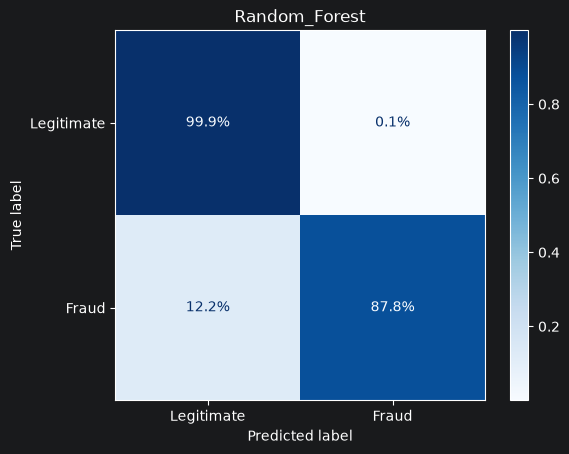

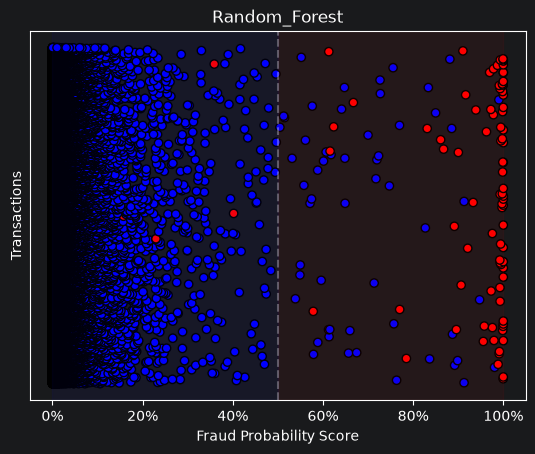

In [9]:
with transactional_mlflow_run(run_name="Random_Forest") as run:
    model_name = "rf"
    run_name_str = str(run.info.run_name)

    def rf_objective(trial: optuna.Trial) -> float:
        rf_params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300),
            "max_depth": trial.suggest_int("max_depth", 5, 15),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical(
                "max_features", ["sqrt", "log2"]
            ),
            "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
        }
        estimator = Pipeline([
            ("robust_scaler", RobustScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            (
                model_name,
                RandomForestClassifier(
                    **rf_params,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=1,
                ),
            ),
        ])
        return float(
            numpy.mean(
                cross_val_score(
                    estimator,
                    train_x_np,
                    train_y_np,
                    cv=CV,
                    scoring="average_precision",
                    n_jobs=1,
                )
            )
        )

    rf_study = optimize_hyperparameters(
        objective=rf_objective,
        multivariate=True,
    )
    rf_best_params = rf_study.best_params
    rf_best_model = Pipeline([
        ("robust_scaler", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        (
            model_name,
            RandomForestClassifier(
                **rf_best_params,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=2,
            ),
        ),
    ]).fit(train_x_np, train_y_np)
    _, rf_metrics, rf_figures = evaluate_model(
        model=rf_best_model,
        model_input=test_x_np,
        y_true=test_y_np,
        title=run_name_str,
    )
    print(run_name_str)
    print(f"  Best Hyperparameters: {rf_best_params}")
    display(pandas.DataFrame(rf_metrics.items(), columns=["Metric", "Score"]))
    rf_model_info = log_model_run(
        model=rf_best_model,
        registered_model_name=run_name_str,
        signature=infer_signature(
            model_input=test_x_np,
            model_output=rf_best_model.predict(test_x_np),
        ),
        input_example=test_x_np[:5],
        pip_requirements=[
            "imbalanced-learn==0.14.2",
            "scikit-learn==1.9.0",
            "numpy==2.5.2",
            "pandas==2.3.3",
        ],
        skops_trusted_types=[
            "imblearn.over_sampling._smote.base.SMOTE",
            "imblearn.pipeline.Pipeline",
            "sklearn.ensemble._forest.RandomForestClassifier",
            "sklearn.tree._classes.DecisionTreeClassifier",
            "sklearn.tree._tree.Tree",
        ],
        params=rf_best_params,
        metrics=rf_metrics,
        figures=rf_figures,
    )

### XGBoost


C:\Users\MSI Laptop\AppData\Local\Temp\ipykernel_18164\3265611493.py:7: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=TPESampler(
[I 2026-10-02 22:39:38,457] A new study created in memory with name: no-name-f2162e3c-574f-41c7-83e0-00271b324215
  0%|          | 0/30 [00:00<?, ?it/s]

[22:39:39] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (341176, 30, 10235280).
[22:39:42] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (341176, 30, 10235280).
[22:39:49] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (341176, 30, 10235280).
[22:39:53] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (341178, 30, 10235340).


  0%|          | 0/30 [00:18<?, ?it/s]

[I 2026-10-02 22:39:56,689] Trial 0 finished with value: 0.8447481962915269 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1001303991139125, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.4936111842654619, 'reg_alpha': 8.629132190071855e-06, 'reg_lambda': 2.4496293433163567e-06, 'gamma': 4.330880728874676, 'min_child_weight': 7}. Best is trial 0 with value: 0.8447481962915269.


Best trial: 0. Best value: 0.844748:   3%|▎         | 1/30 [00:18<08:55, 18.46s/it, 18.46/3600 seconds]

...

[I 2026-10-02 22:47:14,013] Trial 29 finished with value: 0.8503268977876166 and parameters: {'n_estimators': 278, 'max_depth': 10, 'learning_rate': 0.08581779439066534, 'subsample': 0.986834622992265, 'colsample_bytree': 0.4526199828210687, 'reg_alpha': 0.0023683372866893314, 'reg_lambda': 3.896439118289878e-06, 'gamma': 1.290773930135782, 'min_child_weight': 10}. Best is trial 17 with value: 0.8544264537082411.


Best trial: 17. Best value: 0.854426: 100%|██████████| 30/30 [07:35<00:00, 15.19s/it, 455.77/3600 seconds]


[22:47:14] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (454902, 30, 13647060).
XGBoost
  Best Hyperparameters: {'n_estimators': 176, 'max_depth': 10, 'learning_rate': 0.12277253671681762, 'subsample': 0.9251469846961815, 'colsample_bytree': 0.45598518586132225, 'reg_alpha': 3.6417916391731155e-05, 'reg_lambda': 3.3860064110593367e-06, 'gamma': 0.3274886744358434, 'min_child_weight': 10}


,Metric,Score
0,F1 score,0.800000
1,PR-AUC,0.873509
2,Recall,0.857143
3,Precision,0.750000
4,ROC-AUC,0.980383
5,Accuracy,0.999263


2026/10/02 22:47:18 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Projects\Personal\Practice\fraud-detection-platform\notebooks
2026/10/02 22:47:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'XGBoost'.
Created version '1' of model 'XGBoost'.


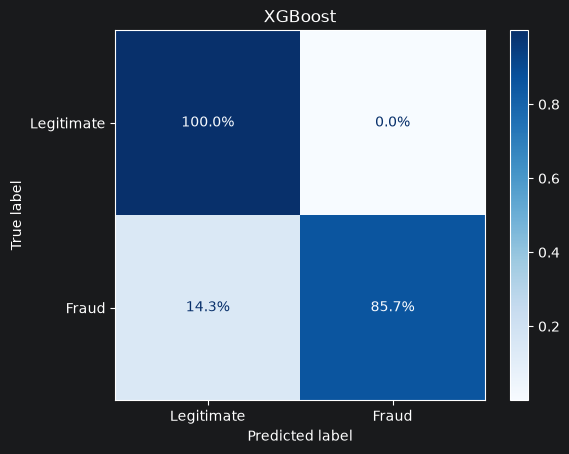

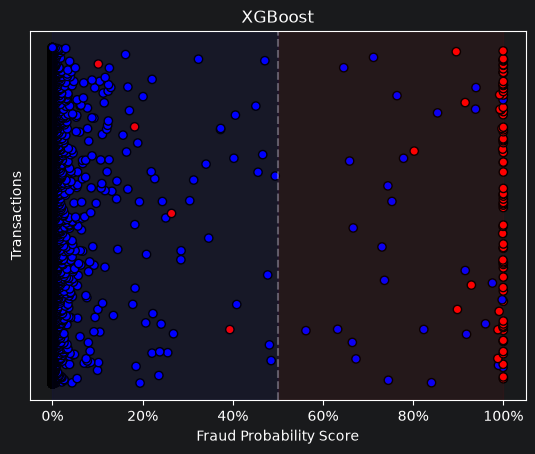

In [10]:
with transactional_mlflow_run(run_name="XGBoost") as run:
    model_name = "xgb"
    run_name_str = str(run.info.run_name)

    def xgb_objective(trial: optuna.Trial) -> float:
        xgb_params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.005, 0.3, log=True
            ),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.4, 1.0
            ),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 5.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        }
        estimator = Pipeline([
            ("robust_scaler", RobustScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            (
                model_name,
                XGBClassifier(
                    **xgb_params,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbosity=2,
                ),
            ),
        ])
        return float(
            numpy.mean(
                cross_val_score(
                    estimator,
                    train_x_np,
                    train_y_np,
                    cv=CV,
                    scoring="average_precision",
                    n_jobs=1,
                )
            )
        )

    xgb_study = optimize_hyperparameters(
        objective=xgb_objective,
        multivariate=True,
    )
    xgb_best_params = xgb_study.best_params
    xgb_best_model = Pipeline([
        ("robust_scaler", RobustScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        (
            model_name,
            XGBClassifier(
                **xgb_best_params,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=2,
            ),
        ),
    ]).fit(train_x_np, train_y_np)
    _, xgb_metrics, xgb_figures = evaluate_model(
        model=xgb_best_model,
        model_input=test_x_np,
        y_true=test_y_np,
        title=run_name_str,
    )
    print(run_name_str)
    print(f"  Best Hyperparameters: {xgb_best_params}")
    display(pandas.DataFrame(xgb_metrics.items(), columns=["Metric", "Score"]))
    xgb_model_info = log_model_run(
        model=xgb_best_model,
        registered_model_name=run_name_str,
        signature=infer_signature(
            model_input=test_x_np,
            model_output=xgb_best_model.predict(test_x_np),
        ),
        input_example=test_x_np[:5],
        pip_requirements=[
            "imbalanced-learn==0.14.2",
            "xgboost==3.4.1",
            "scikit-learn==1.9.0",
            "numpy==2.5.2",
            "pandas==2.3.3",
        ],
        skops_trusted_types=[
            "imblearn.over_sampling._smote.base.SMOTE",
            "imblearn.pipeline.Pipeline",
            "sklearn.metrics._dist_metrics.EuclideanDistance64",
            "sklearn.neighbors._kd_tree.KDTree",
            "xgboost.core.Booster",
            "xgboost.sklearn.XGBClassifier",
        ],
        params=xgb_best_params,
        metrics=xgb_metrics,
        figures=xgb_figures,
    )

### MLP Model


In [11]:
class MLP(nn.Module):
    def __init__(
        self,
        *,
        input_size: int,
        hidden_size: int,
        num_layers: int,
        activation: str,
        dropout: float,
        epochs: int,
        batch_size: int,
        lr: float,
        weight_decay: float,
        device: torch.device,
    ) -> None:
        super().__init__()
        activation_function = ACTIVATION_MAP[activation]

        self.linears = nn.ModuleList()
        self.activations = nn.ModuleList()
        layer_input_size = input_size
        for _ in range(num_layers):
            self.linears.append(nn.Linear(layer_input_size, hidden_size))
            self.activations.append(activation_function())
            layer_input_size = hidden_size
        self.output = nn.Linear(layer_input_size, 1)

        self.dropout = dropout
        self.epochs = epochs
        self.batch_size = batch_size
        self.criterion = nn.BCEWithLogitsLoss()
        self.device = device
        self.to(device)
        self.optimizer = optim.AdamW(
            self.parameters(), lr=lr, weight_decay=weight_decay
        )

    def forward(self, x: Tensor) -> Tensor:
        for linear, activation in zip(self.linears, self.activations):
            x = activation(linear(x))
            x = functional.dropout(x, p=self.dropout, training=self.training)
        return self.output(x).squeeze(1)

    def train_one_epoch(self, train_loader: DataLoader) -> float:
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(self.device)
            batch_y = batch_y.to(self.device)
            self.optimizer.zero_grad()
            batch_logits = self(batch_x)
            loss = self.criterion(batch_logits, batch_y)
            loss.backward()
            self.optimizer.step()
            epoch_loss += loss.item()
        return epoch_loss / len(train_loader)

    def update_progress_bar(
        self,
        pbar: tqdm | None,
        epoch: int,
        epoch_loss: float,
    ) -> None:
        if pbar is not None:
            with pbar.get_lock():
                pbar.reset(total=self.epochs)
                pbar.n = epoch + 1
                pbar.set_postfix(loss=f"{epoch_loss:.4f}")

    def fit(
        self,
        x: ndarray,
        y: ndarray,
        pbar: tqdm | None = None,
    ) -> "MLP":
        train_loader = DataLoader(
            TensorDataset(
                torch.tensor(x, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32),
            ),
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=self.device.type == "cuda",
        )
        self.train()
        for epoch in range(self.epochs):
            epoch_loss = self.train_one_epoch(train_loader=train_loader)
            self.update_progress_bar(
                pbar=pbar,
                epoch=epoch,
                epoch_loss=epoch_loss,
            )
        return self

    def predict_probabilities(self, x: ndarray) -> ndarray:
        self.eval()
        with torch.no_grad():
            tensor = torch.tensor(x, dtype=torch.float32).to(self.device)
            probability = torch.sigmoid(self(tensor)).cpu().numpy()
            return numpy.stack([1 - probability, probability], axis=1)

    def predict(self, x: ndarray, threshold: float = 0.5) -> ndarray:
        probability = self.predict_probabilities(x)[:, 1]
        return (probability >= threshold).astype(int)

    def predict_proba(self, x: ndarray) -> ndarray:
        return self.predict_probabilities(x)

class MLPPipeline(PythonModel):
    def __init__(self, mlp: MLP, robust_scaler: RobustScaler) -> None:
        self.mlp = mlp
        self.robust_scaler = robust_scaler

    def predict(
        self,
        context: PythonModelContext | None,
        model_input: pandas.DataFrame | numpy.ndarray,
        params: dict[str, Any] | None = None,
    ) -> numpy.ndarray:
        params = params or {}

        if isinstance(model_input, pandas.DataFrame):
            model_input = model_input.values
        model_input = self.robust_scaler.transform(model_input)

        if params.get("probabilities", False):
            return self.mlp.predict_proba(model_input)

        return self.mlp.predict(
            model_input,
            threshold=float(params.get("threshold", 0.5)),
        )

C:\Projects\Personal\Practice\fraud-detection-platform\notebooks\.venv\Lib\site-packages\mlflow\pyfunc\model.py:209: UserWarning: Type hint used in the model's predict function is not supported for MLflow's schema validation. Type hints must be wrapped in list[...] because MLflow assumes the predict method to take multiple input instances. Specify your type hint as `list[pandas.core.frame.DataFrame | numpy.ndarray]` for a valid signature. Remove the type hint to disable this warning. To enable validation for the input data, specify input example or model signature when logging the model. 
  func_info = _get_func_info_if_type_hint_supported(predict_attr)


### MLP


MLP: 0it [00:00, ?it/s][I 2026-10-02 22:47:20,935] A new study created in memory with name: no-name-864172a0-c521-4d9e-8a45-3adcd4d03f13

                                                                 
  0%|          | 0/30 [03:22<?, ?it/s]

[I 2026-10-02 22:50:43,875] Trial 0 finished with value: 0.7468279622127147 and parameters: {'hidden_size': 116, 'num_layers': 4, 'activation': 'relu', 'dropout': 0.07799726016810132, 'lr': 1.7073967431528103e-05, 'weight_decay': 0.011567327199145964, 'batch_size': 320, 'epochs': 8}. Best is trial 0 with value: 0.7468279622127147.



Best trial: 0. Best value: 0.746828:   3%|▎         | 1/30 [03:23<1:38:12, 203.18s/it]
                                                                 <1:38:12, 203.18s/it, 203.18/3600 seconds]
Best trial: 0. Best value: 0.746828:   3%|▎         | 1/30 [04:57<1:38:12, 203.18s/it, 203.18/3600 seconds]

[I 2026-10-02 22:52:18,130] Trial 1 finished with value: 0.7427739384055385 and parameters: {'hidden_size': 36, 'num_layers': 4, 'activation': 'relu', 'dropout': 0.09170225492671691, 'lr': 0.00016480446427978953, 'weight_decay': 4.712973756110775e-05, 'batch_size': 256, 'epochs': 5}. Best is trial 0 with value: 0.7468279622127147.



Best trial: 0. Best value: 0.746828:   7%|▋         | 2/30 [04:57<1:04:55, 139.11s/it, 203.18/3600 seconds]
                                                                 <1:04:55, 139.11s/it, 297.44/3600 seconds]
Best trial: 0. Best value: 0.746828:   7%|▋         | 2/30 [05:58<1:04:55, 139.11s/it, 297.44/3600 seconds]

...

[I 2026-10-02 23:47:59,879] Trial 20 finished with value: 0.81987930462746 and parameters: {'hidden_size': 142, 'num_layers': 3, 'activation': 'gelu', 'dropout': 0.10907463661820425, 'lr': 0.0002780352799494497, 'weight_decay': 0.0023126262188929657, 'batch_size': 512, 'epochs': 9}. Best is trial 20 with value: 0.81987930462746.



MLP: 100%|██████████| 9/9 [00:00<00:00, 8962.19it/s, loss=0.0056]

MLP
  Best Hyperparameters: {'hidden_size': 142, 'num_layers': 3, 'activation': 'gelu', 'dropout': 0.10907463661820425, 'lr': 0.0002780352799494497, 'weight_decay': 0.0023126262188929657, 'batch_size': 512, 'epochs': 9}


,Metric,Score
0,F1 score,0.612100
1,PR-AUC,0.835345
2,Recall,0.877551
3,Precision,0.469945
4,ROC-AUC,0.971837
5,Accuracy,0.998086


2026/10/02 23:49:05 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in C:\Projects\Personal\Practice\fraud-detection-platform\notebooks
2026/10/02 23:49:05 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
C:\Projects\Personal\Practice\fraud-detection-platform\notebooks\.venv\Lib\site-packages\mlflow\pyfunc\__init__.py:3271: UserWarning: Failed to infer signature from type hint: Type hints must be wrapped in list[...] because MLflow assumes the predict method to take multiple input instances. Specify your type hint as `list[pandas.core.frame.DataFrame | numpy.ndarray]` for a valid signature.
  signature_from_type_hints = _infer_signature_from_type_h

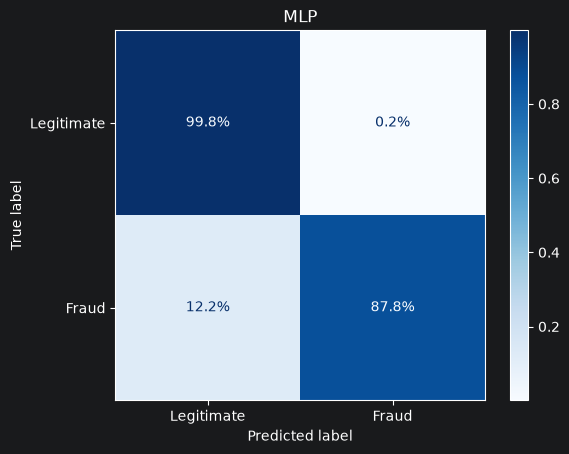

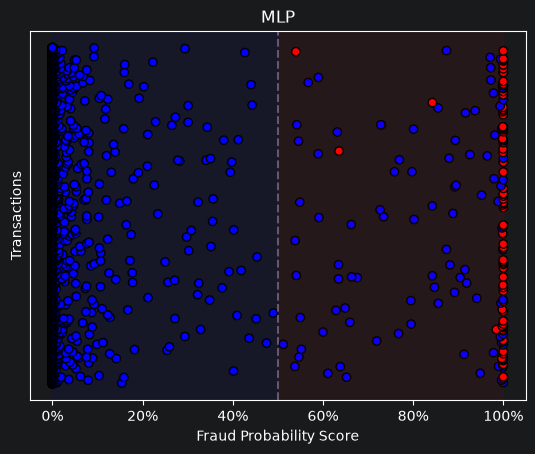

MLP: 100%|██████████| 9/9 [00:02<00:00,  3.33it/s, loss=0.0056]  


In [12]:
def score_mlp_fold(
    *,
    fold_train_x: ndarray,
    fold_train_y: ndarray,
    fold_val_x: ndarray,
    fold_val_y: ndarray,
    mlp_params: dict[str, object],
    pbar: tqdm | None,
) -> float:
    robust_scaler = RobustScaler()
    fold_train_x_scaled = robust_scaler.fit_transform(fold_train_x)
    fold_val_x_scaled = robust_scaler.transform(fold_val_x)

    fold_train_x_scaled, fold_train_y = SMOTE(
        random_state=RANDOM_STATE
    ).fit_resample(fold_train_x_scaled, fold_train_y)

    model = MLP(
        **mlp_params,
        input_size=fold_train_x_scaled.shape[1],
        device=DEVICE,
    ).fit(fold_train_x_scaled, fold_train_y, pbar)

    return average_precision_score(
        fold_val_y,
        model.predict_proba(fold_val_x_scaled)[:, 1],
    )

with transactional_mlflow_run(run_name="MLP") as run:
    run_name_str = str(run.info.run_name)

    with tqdm(desc="MLP", dynamic_ncols=True) as pbar:

        def mlp_objective(trial: optuna.Trial) -> float:
            mlp_params = {
                "hidden_size": trial.suggest_int("hidden_size", 32, 256),
                "num_layers": trial.suggest_int("num_layers", 2, 4),
                "activation": trial.suggest_categorical(
                    "activation", ["relu", "gelu", "silu"]
                ),
                "dropout": trial.suggest_float("dropout", 0.0, 0.5),
                "lr": trial.suggest_float("lr", 1e-5, 0.1, log=True),
                "weight_decay": trial.suggest_float(
                    "weight_decay", 1e-8, 0.1, log=True
                ),
                "batch_size": trial.suggest_int("batch_size", 64, 512, step=64),
                "epochs": trial.suggest_int("epochs", 3, 10),
            }
            fold_scores = []
            for fold_train_indices, fold_val_indices in CV.split(
                train_x_np, train_y_np
            ):
                fold_score = score_mlp_fold(
                    fold_train_x=train_x_np[fold_train_indices],
                    fold_train_y=train_y_np[fold_train_indices],
                    fold_val_x=train_x_np[fold_val_indices],
                    fold_val_y=train_y_np[fold_val_indices],
                    mlp_params=mlp_params,
                    pbar=pbar,
                )
                fold_scores.append(fold_score)
            return float(numpy.mean(fold_scores))

        mlp_study = optimize_hyperparameters(
            objective=mlp_objective,
            multivariate=False,
        )
        mlp_best_params = mlp_study.best_params

        mlp_robust_scaler = RobustScaler()
        train_x_scaled_np = mlp_robust_scaler.fit_transform(train_x_np)
        train_x_scaled_np, train_y_resampled_np = SMOTE(
            random_state=RANDOM_STATE
        ).fit_resample(train_x_scaled_np, train_y_np)
        mlp_best_model = MLPPipeline(
            mlp=MLP(
                **mlp_best_params,
                input_size=train_x_np_dimensions_size,
                device=DEVICE,
            ).fit(train_x_scaled_np, train_y_resampled_np, pbar),
            robust_scaler=mlp_robust_scaler,
        )
        _, mlp_metrics, mlp_figures = evaluate_model(
            model=mlp_best_model,
            model_input=test_x_np,
            y_true=test_y_np,
            title=run_name_str,
        )
        print(run_name_str)
        print(f"  Best Hyperparameters: {mlp_best_params}")
        display(pandas.DataFrame(mlp_metrics.items(), columns=["Metric", "Score"]))
        mlp_model_info = log_model_run(
            model=mlp_best_model,
            registered_model_name=run_name_str,
            signature=infer_signature(
                model_input=test_x_np,
                model_output=mlp_best_model.predict(
                    context=None,
                    model_input=test_x_np
                ),
                params={"probabilities": False, "threshold": 0.5},
            ),
            input_example=test_x_np[:5],
            pip_requirements=[
                "torch==2.14.1",
                "scikit-learn==1.9.0",
                "numpy==2.5.2",
                "pandas==2.3.3",
            ],
            params=mlp_best_params,
            metrics=mlp_metrics,
            figures=mlp_figures,
        )